Arthur Grossmann--Le Mauguen

$$ \text{ML, Signal, Image} $$
$$ \text{Practical session 2 - The sparse model} $$
$$ \text{Clement Elvira} $$
$$ \text{2025-2026} $$

Rq: Partie 1.3 pas à faire, question 1.1.3 passée pour gagner du temps


This second lab revolves around the “sparse model”. The first exercise (Task 1)
is a continuation of the first lab session and should provide a better understanding
of the sparse model. It is designed so that you can (and should) reuse the code
you have already written. The second exercise (Task 2) is an application to image
inpainting. It is (intentionally) less guided and will call on your modeling skills.

1 Task 1: getting started with the sparse model


A close look at the shape of capital letters reveals that they can (almost all) be drawn by combining elementary "symbols". The most striking example is probably provided by the letters "E", "F" and "L", which break down into: i) a vertical bar common to all three letters; ii) a horizontal bar on top for "E" and "F"; iii) etc.
Note that the same vertical bar is also used to draw the letters "D", "K", "P" and "R".  
With this observation in mind, it can be said that any capital letter can be represented as a combination of a few "elementary" symbols from a dictionary. The ultimate goal of this first exercise is thus to identify handwritten capital letters from a small number of linear measurements.

1.1 Introduction

1. Load the dictionary matrix available at “data_task_1/dic.csv”.
In python, you can use the function numpy.loadtxt (click on the function to access the documentation) from the Numpy library with the argument “delimiter=‘,’”. Each one of the 13 columns of the dictionary matrix represents a (vectorized) elementary symbol that can be used to represent a 28 × 28 pixels capital letters.

2. Plot the 13 elementary symbols. What kind of letters can you represent with them?
hint: there is (at least) 12 possible letters. . .  
For simplicity’s sake, we’ll consider that a letter has been correctly identified
if the support of the vector related to its sparse decomposition in the dictionary
makes it possible to find all the elementary symbols necessary for its representation.
To this end, we considered as recovery metric the F1 score designed as

3. Implement a function that evaluates the F1 score.

1.2 Recovery on a toy example

4. Generate a “R” using the dictionary of symbols.
you can use any values for the nonzero weights. I recommend setting them all to 1.
5. What kind of decoder could you use?
6. Describe the problem in terms of the four ingredients.
7. Implement a decoder that returns the support of the sparse representation. What do you conclude?
hint: you can use the Basis Pursuit solver provided with this tutorial, see the python file at data_task_1/bp.py.
We now consider the case where the 28 × 28 image is subsampled. To speed things up, let us consider directly the case where each one of the m "measurements" is obtained by taking the inner product of the image with a random Gaussian matrix.
8. Write the observation model.
9. From a theoretical point of view, how many measurements are (at least) needed to recover the support?
10. Set m = 8, generate of a (random Gaussian) sensing matrix and apply the proposed decoder. Plot the reconstructed image and evaluate the F1 score. Compare the results with what you obtain using the subspace model.
11. Still considering the letter “R” generated above, plot the F1 score as a function of m. For each value of m, you for instance average the F1 score over realizations of the random measurement matrix. Conclude.

1.3 Please Mr. Postman


In this last series of questions, the objective will be to apply our methodology to identify handwritten capital letters.1

12. Load the dataset stored in data_task_1/handwritten.csv. In particular, each one of the 48 columns is a vectorized version of such an 28×28 image.
13. Plot a few of them.
Since perfect image reconstruction is most probably not possible, we can use
the "denoising" version of the Basis Pursuit decoder recalled below.

2 Task 2: application in image inpainting

In this second exercise, we want to restore an image that has been damaged by a hard disk incident. Specifically, we’ll assume that some pixel values are missing. The task will be to restore the missing pixel leveraging the sparse model.  
Fortunately, it is well known in the image processing literature that natural images can be well approximated by their sparse decomposition in a well-chosen redundant dictionary. More precisely, we will use the fact that their “overlapping patch decomposition” admits a sparse decomposition. A patch is defined
as a small piece of image. In this tutorial, we’ll consider 8 × 8 patches. In this way, we can decompose an image by considering all the sub-images of size 8×8, transform them and then recombine them to reconstruct a new image. The term “overlapping” refers to the fact a pixel can be present in several patches.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from data_task_1 import bp

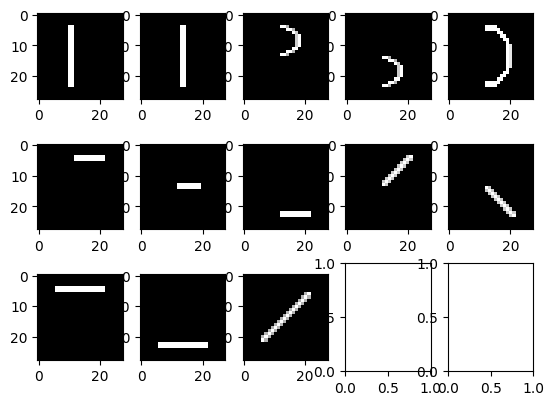

In [14]:
def ImgToVec(Img):
  return np.reshape(Img, -1)

def VecToImg(vec, p1, p2):
  return np.reshape(vec, (p1, p2))

Phi = np.loadtxt('data_task_1/dic.csv', delimiter=',')

f, ax = plt.subplots(3, 5)
for i in range(3):
  for j in range(5):
    idx = i*5+j
    if idx >=13:
      continue
    ax[i, j].imshow(VecToImg(Phi[:,idx], 28, 28), cmap='gray')

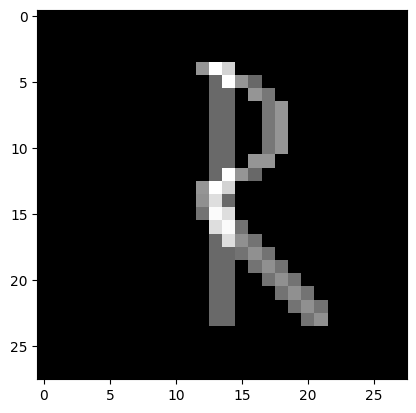

In [15]:
idx_R=[1, 2, 9]
alpha_R = np.zeros(13)
alpha_R[idx_R] = 1

X = Phi @ alpha_R

plt.imshow(VecToImg(X, 28, 28), cmap='gray')

Q6: (cf photo pour maj)
1) observation: M R**784 -> R**m
x -> Mx M appartinet à R ** (m*784)

2) ensemble cible: x target = sigma 5
3) decodeur:
* idéal:
* pratique:
4) identifier la bonne lettre

M' = M phi

In [ ]:
m = 10 # nombre de mesures

M = np.random.randn(m, 784)

y = M@X
print(f"Observation: y={y}")

alpha_hat = bp.bp_solver(M@Phi, y)

Observation: y=[-2.23722746 -1.59681303  0.21450154 -0.74558256  0.4672812  -0.66359204
 -0.90380482  0.7634607 ]


[0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


Text(0.5, 1.0, 'Recovered image')

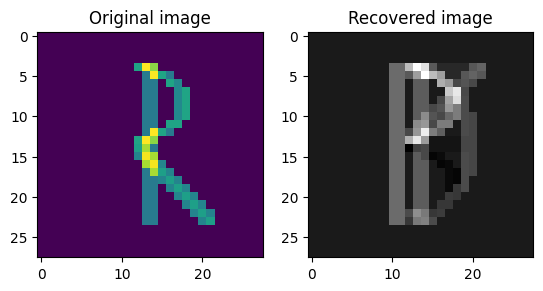

In [26]:
print(alpha_R)

f, ax = plt.subplots(1, 2)
ax[0].imshow(VecToImg(X, 28, 28))
ax[0].set_title('Original image')

ax[1].imshow(VecToImg(Phi@alpha_hat, 28, 28), cmap="gray")
ax[1].set_title('Recovered image')

- ici m=10 avec k appartient {3, 5} (condition nécessaire)
- condition necessaire et suffisante: EkR: n'importe quel sous ensemble de 2k colonne est linéairement indépendant

In [27]:
M_prime=M@Phi
np.linalg.matrix_rank(M_prime)
# il faudrait vérifier tous les rangs de toutes les sous matrices de 2k colonnes et vérifier que plus grand que 6 ou 10

np.int64(8)

Pour le décodeur l1, il faut vérifier une condtion sur la cohérence de la matrice M'

In [28]:
M_prime_normalized = np.copy(M_prime)
for j in range(13):
  M_prime_normalized[:, j] /=np.linalg.norm(M_prime_normalized[:, j],2)

G = np.abs(M_prime_normalized.T @ M_prime_normalized - np.eye(13)) #pour avoir 0 sur la diagonale (modulo précsion machine)
G[:3, :3] # affiche 3 premières colonnes et lignes

mu = np.max(G)

In [29]:
print(f"mu={mu}")
print(f"1 / (2k-1) = {1 / (9)}")

mu=0.8444324800151461
1 / (2k-1) = 0.1111111111111111


fin tache 1

In [30]:
s2 = 0.1
y_b = y + np.sqrt(s2) * np.random.randn(m)

print(f"||y - y_b|| = {np.linalg.norm(y - y_b, 2)}")

||y - y_b|| = 0.6064869790165476


[ 0.54930261  0.447804    0.47082181 -0.09758281  0.36063673  0.07109012
 -0.02375674 -0.          0.28831427 -0.         -0.         -0.
 -0.        ]
[ 0.65864663  0.1520121   0.33192067 -0.45254042  0.27326947  0.3433077
  0.25388953 -0.          0.45979821 -0.         -0.         -0.
 -0.        ]


Text(0.5, 1.0, 'Image bruitée reconstruite avec BP')

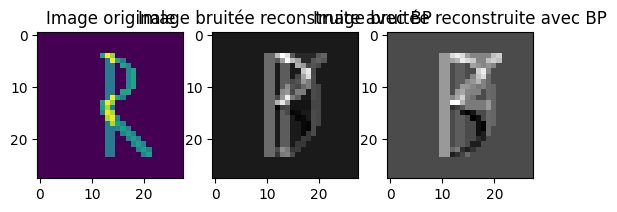

In [31]:
# reconstruction du signal

alpha_hat_b = bp.bp_solver(M@Phi, y_b)

print(alpha_hat)
print(alpha_hat_b)

f, ax = plt.subplots(1, 3)
ax[0].imshow(VecToImg(X, 28, 28))
ax[0].set_title('Image originale')

ax[1].imshow(VecToImg(Phi@alpha_hat, 28, 28), cmap="gray")
ax[1].set_title('Image bruitée reconstruite avec BP')

ax[2].imshow(VecToImg(Phi@alpha_hat_b, 28, 28), cmap="gray")
ax[2].set_title('Image bruitée reconstruite avec BP')